# Expected remanence directions in the Duluth Complex

The D-6A drill core samples the South Kawishiwi intrusion, one of the mafic
layered intrusions that make up the ~1096 Ma Duluth Complex. Before we
interpret the paleomagnetic directions measured from D-6A, it is useful to
establish *what direction we should expect* the primary Keweenawan remanence to
record in the anorthositic and layered series of the complex.

This notebook develops that expectation from two data sources:

1. **Compiled data** — the site-level directions of {cite:t}`Beck1970a` for the
   anorthositic series, layered series, and related units of the Duluth
   Complex. These are read from a local copy of the compilation used in
   {cite:t}`Swanson-Hysell2021c`.
2. **New data** — the new Duluth Complex sites (FC1, FC4, HCT1) of
   {cite:t}`Swanson-Hysell2021c`, brought in directly from the MagIC data
   archive (contribution [17073](https://earthref.org/MagIC/17073),
   {cite:t}`Swanson-Hysell2021c`) using the PmagPy `Contribution` object.

Both datasets record a shallow-to-moderate, west-to-northwest-directed,
down-pointing remanence — the normal-polarity Keweenawan direction — which
sets the expectation for the D-6A core.

The D-6A core adds two further complications, developed in the final sections:
the Duluth Complex was tilted after it was magnetized — by a different amount in
different parts of the complex — and the core is azimuthally unoriented so only
its **inclination** can be interpreted.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pmagpy.contribution_builder as cb

# Data lives in pmag_data/ next to this notebook; locate it whether the notebook
# is run from its own directory or from the repository root.
pmag_data = next(p / 'pmag_data' for p in (Path.cwd(), Path('Duluth_Complex_background'))
                 if (p / 'pmag_data').is_dir())


-W- cartopy is not installed
    If you want to make maps, install using conda:
    conda install cartopy


## Compiled Duluth Complex directions (Beck, 1970)

{cite:t}`Beck1970a` reported blanket-demagnetized site-mean directions from
across the Duluth Complex. The compilation groups sites by intrusive unit; here
we pull out the **anorthositic series** and the **layered series**, the two
units most relevant to the D-6A core. The directions are in geographic
(*in situ*) coordinates.

In [2]:
beck = pd.read_csv(
    pmag_data / 'pmag_compiled' / 'Beck1969a_sites.txt', sep='\t', header=1
)

anorthositic = beck[beck['location'] == 'Anorthositic series']
layered = beck[beck['location'] == 'Layered series']

print(f'anorthositic series: {len(anorthositic)} sites')
print(f'layered series:      {len(layered)} sites')
beck['location'].value_counts()


anorthositic series: 11 sites
layered series:      38 sites


location
Layered series               38
Lester River Sill            20
Early gabbro series          14
Endion Sill                  13
Basaltic dike                12
Anorthositic series          11
Cook County diabase           6
Brule Hovland gabbro          4
Logan intrusive               3
Eagle Mountain granophyre     2
Felsic series                 2
Duluth diabase                1
Duluth dike (Ely's Peak)      1
Pine Mountain granophyre      1
Name: count, dtype: int64

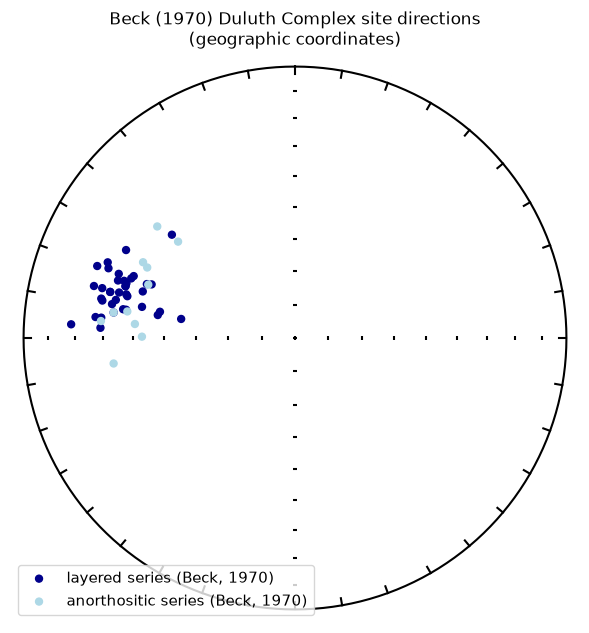

In [3]:
fig = plt.figure(figsize=(6, 6))
ipmag.plot_net()
ipmag.plot_di(layered['dir_dec'].tolist(), layered['dir_inc'].tolist(),
              color='darkblue', label='layered series (Beck, 1970)', markersize=25)
ipmag.plot_di(anorthositic['dir_dec'].tolist(), anorthositic['dir_inc'].tolist(),
              color='lightblue', label='anorthositic series (Beck, 1970)', markersize=25)
plt.legend(loc=3, fontsize=11)
plt.title('Beck (1970) Duluth Complex site directions\n(geographic coordinates)')
plt.show()


Both series define a tight cluster in the northwest quadrant with moderate
positive (downward) inclination. Fisher means quantify the expectation:

In [4]:
beck_means = {}
for name, df in [('anorthositic series', anorthositic), ('layered series', layered)]:
    fm = ipmag.fisher_mean(dec=df['dir_dec'].tolist(), inc=df['dir_inc'].tolist())
    beck_means[name] = fm
    print(f"{name:>20}:  D = {fm['dec']:6.1f}   I = {fm['inc']:5.1f}   "
          f"a95 = {fm['alpha95']:4.1f}   k = {fm['k']:5.1f}   n = {fm['n']}")


 anorthositic series:  D =  285.1   I =  38.5   a95 =  7.5   k =  37.9   n = 11
      layered series:  D =  284.9   I =  34.2   a95 =  2.7   k =  77.7   n = 38


## New Duluth Complex directions from MagIC (contribution 17073)

The directions of {cite:t}`Swanson-Hysell2021c` are archived in the MagIC
database as contribution [17073](https://earthref.org/MagIC/17073). Rather than
reading local files, we download the contribution and unpack it into the
standard MagIC data tables, then load it with the PmagPy `Contribution`
object. The download is cached locally so the notebook only reaches the network
the first time it is run.

In [5]:
import urllib.request

magic_dir = pmag_data / 'pmag_new_MagIC'
magic_dir.mkdir(parents=True, exist_ok=True)
combined_file = magic_dir / 'magic_contribution_17073.txt'

# Download the combined contribution file from MagIC if it is not already cached.
if not combined_file.exists():
    url = 'https://earthref.org/MagIC/download/17073'
    print(f'downloading {url}')
    urllib.request.urlretrieve(url, combined_file)

# Unpack the single combined file into the individual MagIC tables
# (locations.txt, sites.txt, samples.txt, ...).
ipmag.download_magic(combined_file.name, dir_path=str(magic_dir),
                     input_dir_path=str(magic_dir))


working on:  'contribution'
1  records written to file  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/Duluth_Complex_background/pmag_data/pmag_new_MagIC/contribution.txt
contribution  data put in  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/Duluth_Complex_background/pmag_data/pmag_new_MagIC/contribution.txt
working on:  'locations'
1  records written to file  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/Duluth_Complex_background/pmag_data/pmag_new_MagIC/locations.txt
locations  data put in  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/Duluth_Complex_background/pmag_data/pmag_new_MagIC/locations.txt
working on:  'sites'
11  records written to file  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/Duluth_Complex_background/pmag_data/pmag_new_MagIC/sites.txt
sites  data put in  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/Duluth_Complex_background/pmag_data/pmag_new_MagIC/sites.txt
working on:  'samples'
34  records written to file  /Users/penok

True

In [6]:
# Load the contribution with the PmagPy Contribution object.
contribution = cb.Contribution(str(magic_dir))
print('tables:', list(contribution.tables.keys()))

magic_sites = contribution.tables['sites'].df.reset_index()
magic_sites[['site', 'dir_comp_name', 'dir_dec', 'dir_inc',
             'dir_alpha95', 'dir_k', 'dir_n_samples', 'method_codes']]


-I- Using online data model


-I- Getting method codes from earthref.org


-I- Importing controlled vocabularies from https://earthref.org


tables: ['measurements', 'specimens', 'samples', 'sites', 'locations', 'contribution']


,site,dir_comp_name,dir_dec,dir_inc,dir_alpha95,dir_k,dir_n_samples,method_codes
0,FC1,lc,91.0,49.1,6.9,56,9,LP-DIR-AF:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM
1,FC1,lt,35.3,80.9,17.8,9,9,LP-DIR-T:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM
2,FC1,mc,301.6,40.5,9.3,32,9,LP-DIR-AF:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM
3,FC1,mt,289.7,34.4,6.5,64,9,LP-DIR-T:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM
4,FC4,lc,345.9,-47.7,77.8,2,6,LP-DIR-AF:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM
5,FC4,llc,97.7,13.1,180.0,2,2,LP-DIR-AF:DE-BFL:DA-DIR-GEO:LP-DC4
6,FC4,mc,296.0,26.8,7.9,59,7,LP-DIR-AF:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM
7,HCT1,lc,173.3,41.9,39.8,4,6,LP-DIR-AF:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM
8,HCT1,lt,167.0,62.4,47.1,2,8,LP-DIR-T:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM
9,HCT1,mc,287.2,35.6,8.3,54,7,LP-DIR-AF:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM


Each site carries several demagnetization components. The low-stability
components (`lc` from AF, `lt` from thermal) are scattered viscous/overprint
directions, while the **medium-stability components** (`mc` from AF, `mt` from
thermal) isolate the characteristic Keweenawan remanence. We select those
characteristic components to compare with the Beck compilation.

In [7]:
characteristic = magic_sites[magic_sites['dir_comp_name'].isin(['mc', 'mt'])].copy()
characteristic[['site', 'dir_comp_name', 'dir_dec', 'dir_inc', 'dir_alpha95']]


,site,dir_comp_name,dir_dec,dir_inc,dir_alpha95
2,FC1,mc,301.6,40.5,9.3
3,FC1,mt,289.7,34.4,6.5
6,FC4,mc,296.0,26.8,7.9
9,HCT1,mc,287.2,35.6,8.3
10,HCT1,mt,285.7,45.3,5.6


In [8]:
char_mean = ipmag.fisher_mean(dec=characteristic['dir_dec'].tolist(),
                              inc=characteristic['dir_inc'].tolist())
print(f"New Duluth Complex sites, characteristic remanence (Swanson-Hysell et al., 2021):")
print(f"  D = {char_mean['dec']:.1f}   I = {char_mean['inc']:.1f}   "
      f"a95 = {char_mean['alpha95']:.1f}   k = {char_mean['k']:.1f}   n = {char_mean['n']}")


New Duluth Complex sites, characteristic remanence (Swanson-Hysell et al., 2021):
  D = 292.2   I = 36.7   a95 = 8.2   k = 87.3   n = 5


## Combined expectation for the D-6A core

Plotting the compiled Beck directions together with the new Duluth Complex
characteristic directions shows that both datasets record the same
normal-polarity Keweenawan direction.

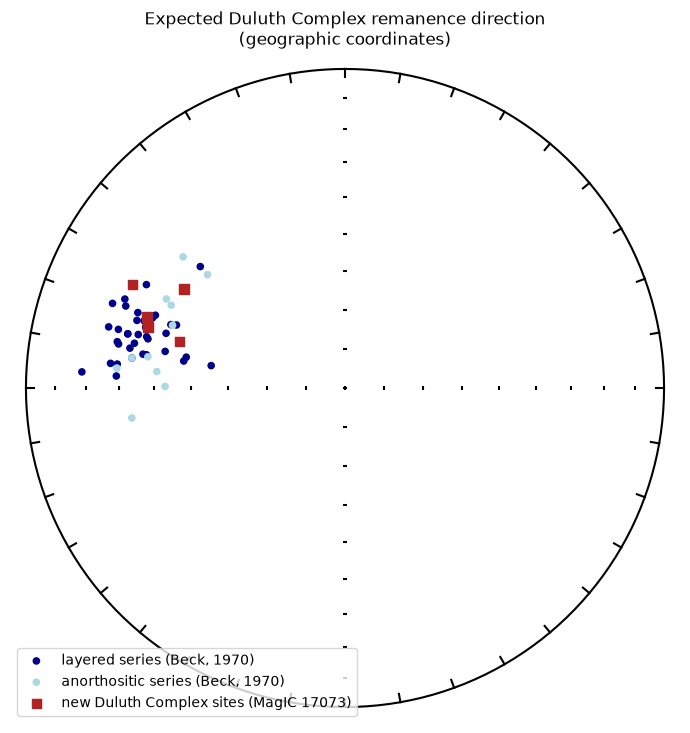

In [9]:
fig = plt.figure(figsize=(7, 7))
ipmag.plot_net()

# Compiled Beck (1970) site directions.
ipmag.plot_di(layered['dir_dec'].tolist(), layered['dir_inc'].tolist(),
              color='darkblue', label='layered series (Beck, 1970)', markersize=20)
ipmag.plot_di(anorthositic['dir_dec'].tolist(), anorthositic['dir_inc'].tolist(),
              color='lightblue', label='anorthositic series (Beck, 1970)', markersize=20)

# New Duluth Complex characteristic directions from MagIC 17073.
ipmag.plot_di(characteristic['dir_dec'].tolist(), characteristic['dir_inc'].tolist(),
              color='firebrick', label='new Duluth Complex sites (MagIC 17073)',
              markersize=45, marker='s')

plt.legend(loc=3, fontsize=10)
plt.title('Expected Duluth Complex remanence direction\n(geographic coordinates)')
plt.show()


In [10]:
print('In-situ (geographic) site-mean directions:')
print(f"  anorthositic series (Beck, 1970):        "
      f"D = {beck_means['anorthositic series']['dec']:.1f}, "
      f"I = {beck_means['anorthositic series']['inc']:.1f}")
print(f"  layered series (Beck, 1970):             "
      f"D = {beck_means['layered series']['dec']:.1f}, "
      f"I = {beck_means['layered series']['inc']:.1f}")
print(f"  new Duluth Complex sites (MagIC 17073):  "
      f"D = {char_mean['dec']:.1f}, I = {char_mean['inc']:.1f}")


In-situ (geographic) site-mean directions:
  anorthositic series (Beck, 1970):        D = 285.1, I = 38.5
  layered series (Beck, 1970):             D = 284.9, I = 34.2
  new Duluth Complex sites (MagIC 17073):  D = 292.2, I = 36.7


## Tilt-correcting the reference directions

The directions above are all in geographic (*in situ*) coordinates
(`dir_tilt_correction = 0`): they are as-measured in rocks that have been tilted
since they were magnetized. To recover the **primary** Keweenawan direction we
restore each dataset to paleohorizontal using the local structural tilt — and,
critically, that tilt differs from place to place across the complex. Following
{cite:t}`Swanson-Hysell2021c`, we use the mean of published igneous-layering
orientations:

- **Beck Duluth-area sites** (anorthositic + layered series) are corrected with
  the West Duluth and Duluth Heights layering measurements.
- **New Duluth Complex sites** (FC/HCT) are corrected with the Houghtaling Creek
  Troctolite layering measurements.

The mean bedding attitude is found by taking the Fisher mean of the poles to the
measured planes, exactly as in the 2020 Duluth Complex analysis.

In [11]:
orientations_dir = pmag_data / 'intrusive_orientations'


def layering(filename, structures=('IL', 'IM', 'IU', 'IT')):
    """Igneous-layering rows (given STRUCTURE codes) from an orientations file."""
    df = pd.read_csv(orientations_dir / filename)
    return df[df['STRUCTURE'].isin(structures)]


def mean_bedding_tilt(planes):
    """Mean bedding (dip_direction, dip) from the Fisher mean of the plane poles."""
    pole = ipmag.fisher_mean((planes['DIPD_TREND'] - 180).tolist(),
                             (90 - planes['DIP_PLUNGE']).tolist())
    return (pole['dec'] + 180) % 360, 90 - pole['inc']


# Beck Duluth-area tilt: West Duluth + Duluth Heights layering, shallow dips only.
west = layering('West_Duluth_orientations.csv')
heights = layering('Duluth_Heights_orientations.csv')
duluth_area = pd.concat([west, heights[heights['Y'] < 5183000]])
beck_dipdir, beck_dip = mean_bedding_tilt(duluth_area[duluth_area['DIP_PLUNGE'] < 35])

# New-site (FC/HCT) tilt: Houghtaling Creek Troctolite layering, shallow dips only.
hct = layering('HCT_WLFG_geochron_orientations.csv', structures=('IL', 'IM', 'IU'))
hct = hct[(hct['DIP_PLUNGE'] < 25) & (hct['DIPD_TREND'] < 220)]
fc_dipdir, fc_dip = mean_bedding_tilt(hct)

print(f'Beck Duluth-area tilt:   dip direction {beck_dipdir:.0f}°, dip {beck_dip:.0f}°')
print(f'new sites (FC/HCT) tilt: dip direction {fc_dipdir:.0f}°, dip {fc_dip:.0f}°')


Beck Duluth-area tilt:   dip direction 85°, dip 18°
new sites (FC/HCT) tilt: dip direction 139°, dip 13°


In [12]:
def tilt_correct(df, dip_direction, dip):
    """Return (dec, inc) lists tilt-corrected to paleohorizontal for a site table."""
    corrected = [pmag.dotilt(dec, inc, dip_direction, dip)
                 for dec, inc in zip(df['dir_dec'], df['dir_inc'])]
    return [c[0] for c in corrected], [c[1] for c in corrected]


# In-situ (geographic) directions for all reference sites, for comparison.
all_dec = (anorthositic['dir_dec'].tolist() + layered['dir_dec'].tolist()
           + characteristic['dir_dec'].tolist())
all_inc = (anorthositic['dir_inc'].tolist() + layered['dir_inc'].tolist()
           + characteristic['dir_inc'].tolist())

anor_dec_tc, anor_inc_tc = tilt_correct(anorthositic, beck_dipdir, beck_dip)
layer_dec_tc, layer_inc_tc = tilt_correct(layered, beck_dipdir, beck_dip)
char_dec_tc, char_inc_tc = tilt_correct(characteristic, fc_dipdir, fc_dip)

primary_dec = anor_dec_tc + layer_dec_tc + char_dec_tc
primary_inc = anor_inc_tc + layer_inc_tc + char_inc_tc
primary_mean = ipmag.fisher_mean(dec=primary_dec, inc=primary_inc)

print('tilt-corrected (primary) means:')
for name, d, i in [('anorthositic', anor_dec_tc, anor_inc_tc),
                   ('layered', layer_dec_tc, layer_inc_tc),
                   ('new sites (FC/HCT)', char_dec_tc, char_inc_tc)]:
    fm = ipmag.fisher_mean(dec=d, inc=i)
    print(f"  {name:>15}:  D = {fm['dec']:6.1f}, I = {fm['inc']:5.1f}, "
          f"a95 = {fm['alpha95']:4.1f}")
print(f"  {'GRAND primary':>15}:  D = {primary_mean['dec']:6.1f}, "
      f"I = {primary_mean['inc']:5.1f}, a95 = {primary_mean['alpha95']:4.1f}, "
      f"n = {primary_mean['n']}")


tilt-corrected (primary) means:
     anorthositic:  D =  292.6, I =  54.8, a95 =  7.5
          layered:  D =  291.1, I =  50.5, a95 =  2.7
  new sites (FC/HCT):  D =  286.5, I =  47.6, a95 =  8.2
    GRAND primary:  D =  291.0, I =  51.1, a95 =  2.4, n = 54


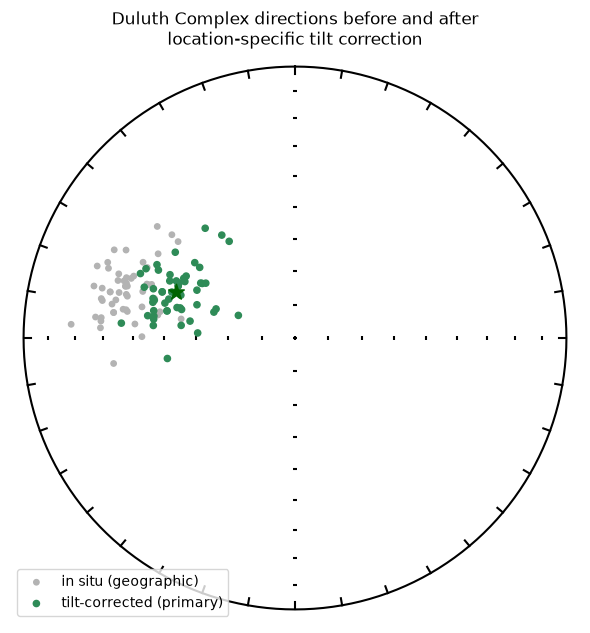

In [13]:
fig = plt.figure(figsize=(6, 6))
ipmag.plot_net()
ipmag.plot_di(all_dec, all_inc, color='0.7', markersize=15,
              label='in situ (geographic)')
ipmag.plot_di(primary_dec, primary_inc, color='seagreen', markersize=20,
              label='tilt-corrected (primary)')
ipmag.plot_di([primary_mean['dec']], [primary_mean['inc']],
              color='darkgreen', markersize=140, marker='*')
plt.legend(loc=3, fontsize=10)
plt.title('Duluth Complex directions before and after\n'
          'location-specific tilt correction')
plt.show()


Restoring each dataset with its own structural tilt brings the anorthositic
series, layered series, and new Duluth Complex sites into agreement on a single
**primary** normal-polarity Keweenawan direction that is steeper than any of the
in-situ groups (I ≈ 51°). This is the direction the rocks recorded when they
were magnetized, before tilting.

## Predicting the inclination in the unoriented D-6A core

The D-6A core samples the South Kawishiwi intrusion, a different part of the
complex with its **own** structural tilt (~15° toward a dip direction of ~135°,
down to the southeast). Two steps give the expected core inclination:

1. **Apply the D-6A tilt** to the primary direction. Because the D-6A tilt axis is
   oblique to the remanence, this rotation **shallows** the inclination relative
   to the steep primary direction.
2. **Collapse to inclination only.** D-6A is azimuthally unoriented — each piece
   can be rotated arbitrarily about the (vertical) core axis, so its declination
   carries no geographic meaning. A single expected direction therefore maps to a
   *small circle of constant inclination* (every declination) on the equal-area
   net, and measured D-6A directions would fall on that circle regardless of
   their arbitrary declinations if they carry this expected direction.

In [14]:
# Structural tilt of the D-6A (South Kawishiwi intrusion) part of the complex.
d6a_dip_direction, d6a_dip = 135.0, 15.0

# Apply the D-6A tilt to the primary direction. pmag.dotilt with a *negative* dip
# adds a tilt (a positive dip removes one), rotating the paleohorizontal primary
# direction into the tilted D-6A reference frame.
d6a_dec, d6a_inc = pmag.dotilt(primary_mean['dec'], primary_mean['inc'],
                               d6a_dip_direction, -d6a_dip)

print(f"primary (tilt-corrected):        D = {primary_mean['dec']:.1f}, "
      f"I = {primary_mean['inc']:.1f}")
print(f"expected in D-6A (15°/135° tilt): D = {d6a_dec:.1f}, I = {d6a_inc:.1f}")
print(f"expected D-6A inclination:       I ≈ {d6a_inc:.0f}°")


primary (tilt-corrected):        D = 291.0, I = 51.1
expected in D-6A (15°/135° tilt): D = 296.3, I = 37.2
expected D-6A inclination:       I ≈ 37°


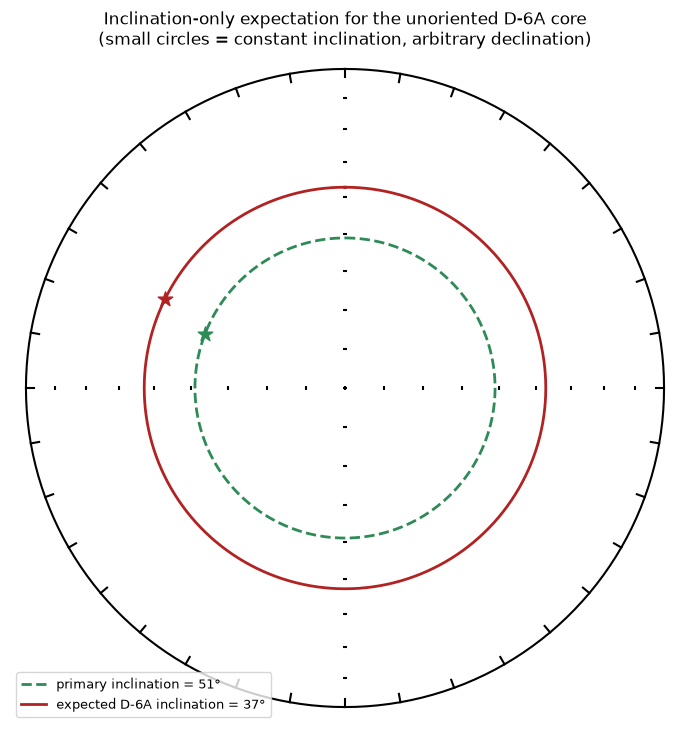

In [15]:
def inclination_small_circle(inc, n=361):
    """Equal-area (x, y) of the constant-inclination small circle (all declinations)."""
    decs = np.linspace(0.0, 360.0, n)
    xy = np.array([pmag.dimap(dec, inc) for dec in decs])
    return xy[:, 0], xy[:, 1]


fig = plt.figure(figsize=(7, 7))
ipmag.plot_net()

# Primary (tilt-corrected) direction and its inclination circle, for reference.
x_p, y_p = inclination_small_circle(primary_mean['inc'])
plt.plot(x_p, y_p, color='seagreen', lw=2, ls='--',
         label=f"primary inclination = {primary_mean['inc']:.0f}°")
ipmag.plot_di([primary_mean['dec']], [primary_mean['inc']],
              color='seagreen', markersize=120, marker='*')

# Expected D-6A inclination after applying the 15°/135° tilt: the small circle
# the unoriented core's directions should fall on.
x_d, y_d = inclination_small_circle(d6a_inc)
plt.plot(x_d, y_d, color='firebrick', lw=2,
         label=f'expected D-6A inclination = {d6a_inc:.0f}°')
ipmag.plot_di([d6a_dec], [d6a_inc], color='firebrick', markersize=120, marker='*')

plt.legend(loc=3, fontsize=9)
plt.title('Inclination-only expectation for the unoriented D-6A core\n'
          '(small circles = constant inclination, arbitrary declination)')
plt.show()


**Expectation for D-6A.** Restored to paleohorizontal, the Duluth Complex
carries a normal-polarity Keweenawan remanence with a steep primary inclination
(I ≈ 51°). Applying the ~15° toward 135° structural tilt of the South Kawishiwi
intrusion **shallows** this to an expected in-situ inclination of roughly 37° in
the D-6A rocks. Because the core is azimuthally unoriented, its declination is
arbitrary and only inclination is meaningful — so the primary magnetization
should appear as directions scattered around the **constant-inclination small
circle at I ≈ 37°** (the solid red circle above). Core directions that instead sit
at steep, near-vertical inclinations are candidates for a present-field viscous or
lightning-induced overprint rather than the primary ~1096 Ma magnetization.